In [1]:
# -----------------------------
# 0. INSTALLATION NOTE
# -----------------------------
# Run this once in a notebook cell if the packages are not installed:
# ! pip install pandas numpy matplotlib seaborn plotly squarify joypy scipy pyjanitor kaleido

In [2]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import joypy
import plotly.graph_objects as go
import re

warnings.filterwarnings("ignore")

In [3]:
# -----------------------------
# 2. REPRODUCIBLE CONFIGURATION
# -----------------------------

# Reproducible paths
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "Final_data_model.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colors from the R project
COL_TEAL = "#69b3a2"
COL_RED = "#e74c3c"
COL_GREY = "lightgrey"

# Font fallback: Geologica if installed, otherwise DejaVu Sans
FONT_MAIN = "Geologica"

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# -----------------------------
# 3. GLOBAL THEME
# -----------------------------

def set_unified_theme():
    """Apply a unified visual style similar to the R theme_unified()."""
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [FONT_MAIN, "DejaVu Sans", "Arial"],
        "axes.titlesize": 22,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.title_fontsize": 11,
        "legend.fontsize": 10,
        "figure.titlesize": 22,
    })


def save_fig(fig, filename):
    """Save matplotlib figures reproducibly into outputs/figures."""
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


set_unified_theme()

In [5]:
# -----------------------------
# 4. DATA LOAD AND PREPROCESSING
# -----------------------------

def load_and_preprocess_data(path):
    df = pd.read_csv(path)

    def clean_column_name(name):
        name = str(name).strip().lower()
        name = re.sub(r"[()/%]", "", name)
        name = re.sub(r"[^a-z0-9]+", "_", name)
        name = re.sub(r"_+", "_", name)
        return name.strip("_")

    df.columns = [clean_column_name(col) for col in df.columns]
    
    # Rename selected columns for easier access
    rename_map = {
        "water_intake_liters": "water_l",
        "session_duration_hours": "duration_hrs",
        "difficulty_level": "difficulty_level",
        "calories_burned": "calories_burned",
        "workout_type": "workout_type",
        "avg_bpm": "avg_bpm",
        "resting_bpm": "resting_bpm",
        "max_bpm": "max_bpm",
        "fat_percentage": "fat_percentage",
        "gender": "gender",
        "weight_kg": "weight_kg",
        "workout_frequency_days_week": "workout_frequency_days_week",
    }

    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # Ordered categorical variables
    df["difficulty_level"] = pd.Categorical(
        df["difficulty_level"],
        categories=["Beginner", "Intermediate", "Advanced"],
        ordered=True,
    )

    df["meal_type"] = pd.Categorical(
        df["meal_type"],
        categories=["Breakfast", "Lunch", "Dinner", "Snack"],
        ordered=True,
    )

    # Create caloric burn categories
    df["burn_category"] = pd.cut(
        df["calories_burned"],
        bins=[-np.inf, 400, 800, np.inf],
        labels=["Low Burn", "Med Burn", "High Burn"],
        right=False,
    )

    df["burn_category"] = pd.Categorical(
        df["burn_category"],
        categories=["Low Burn", "Med Burn", "High Burn"],
        ordered=True,
    )

    return df


df = load_and_preprocess_data(DATA_PATH)

print(df.shape)
df.head()

(20000, 55)


,age,gender,weight_kg,height_m,max_bpm,avg_bpm,resting_bpm,duration_hrs,calories_burned,workout_type,...,pct_carbs,protein_per_kg,pct_hrr,pct_maxhr,cal_balance,lean_mass_kg,expected_burn,burns_calories_per_30_min_bc,burns_calories_bin,burn_category
0,34.91,Male,65.592923,1.62,158.647531,135.542391,86.838582,0.810686,513.155296,Cardio,...,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Low,Med Burn
1,23.37,Female,56.410000,1.55,165.244978,116.702269,77.281148,1.270820,576.245857,Strength,...,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,Med Burn
2,33.20,Female,59.141921,1.67,160.014254,161.811856,89.557526,0.607471,471.256240,HIIT,...,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,Med Burn
3,38.69,Female,94.152458,1.70,189.348708,154.495497,48.857641,1.553248,1698.306387,Strength,...,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,High Burn
4,45.09,Male,54.454370,1.88,180.432454,92.706098,38.240459,1.061695,313.271030,Yoga,...,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,Low Burn


Saved: /Users/ola/Desktop/studia/magisterka-uw/4-semestr/reproducible-research/Project_RR/ReproducibleResearch/outputs/figures/01_treemap_plate_under_microscope.png


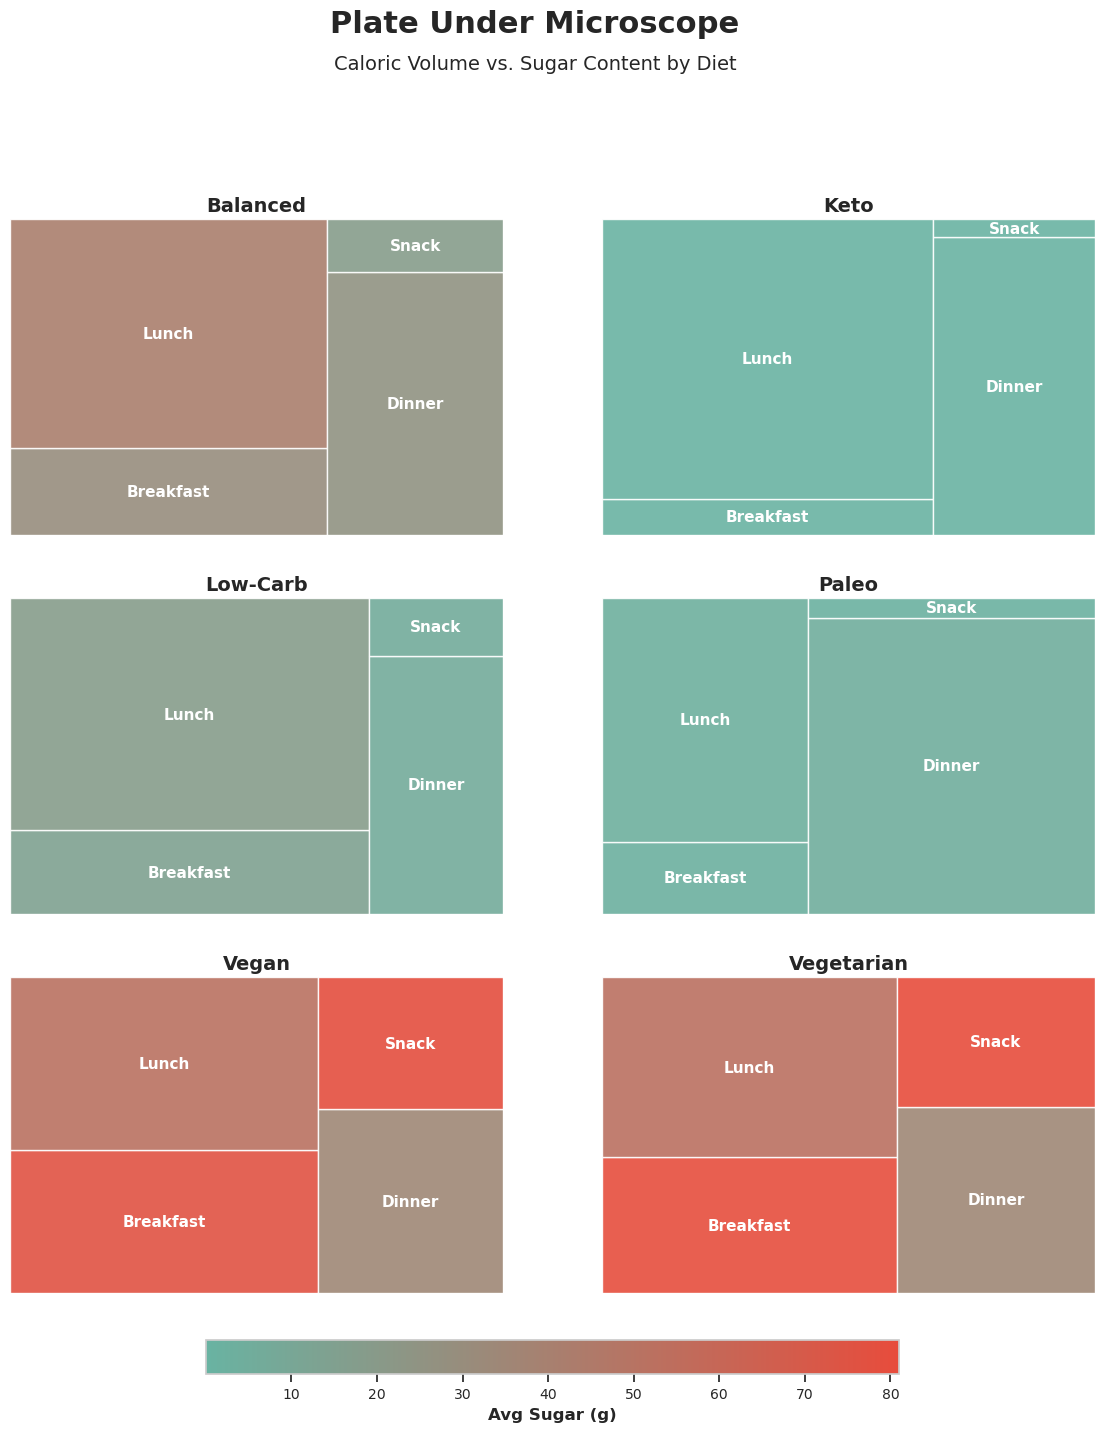

In [6]:
# ============================================================
# PLOT 1: TREEMAP — Plate Under Microscope
# ============================================================

tree_data = (
    df.groupby(["diet_type", "meal_type"], observed=True)
    .agg(
        total_calories=("calories", "sum"),
        avg_sugar=("sugar_g", "mean")
    )
    .reset_index()
)

diets = tree_data["diet_type"].dropna().unique()
n_diets = len(diets)
cols = 2
rows = int(np.ceil(n_diets / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

norm = plt.Normalize(tree_data["avg_sugar"].min(), tree_data["avg_sugar"].max())
cmap = sns.color_palette("blend:#69b3a2,#e74c3c", as_cmap=True)

for ax, diet in zip(axes, diets):
    subset = tree_data[tree_data["diet_type"] == diet]
    colors = [cmap(norm(x)) for x in subset["avg_sugar"]]

    squarify.plot(
        sizes=subset["total_calories"],
        label=subset["meal_type"].astype(str),
        color=colors,
        alpha=0.9,
        ax=ax,
        text_kwargs={"color": "white", "weight": "bold", "fontsize": 11},
    )

    ax.set_title(str(diet), fontsize=14, weight="bold")
    ax.axis("off")

for ax in axes[len(diets):]:
    ax.axis("off")

fig.suptitle("Plate Under Microscope", weight="bold", y=1.02)
fig.text(
    0.5, 0.98,
    "Caloric Volume vs. Sugar Content by Diet",
    ha="center",
    fontsize=14,
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.03, pad=0.04)
cbar.set_label("Avg Sugar (g)", weight="bold")

save_fig(fig, "01_treemap_plate_under_microscope.png")
plt.show()

Saved: /Users/ola/Desktop/studia/magisterka-uw/4-semestr/reproducible-research/Project_RR/ReproducibleResearch/outputs/figures/02_faceted_radar_nutrition.png


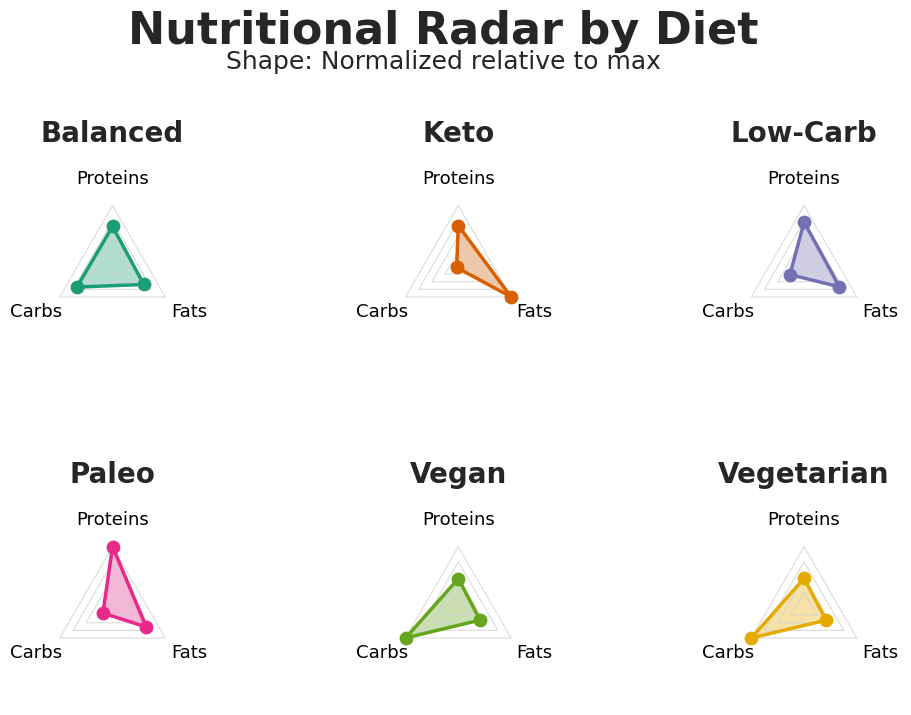

In [7]:
# ============================================================
# PLOT 2: CARTESIAN RADAR CHART 
# ============================================================

metrics = ["proteins", "fats", "carbs"]
metric_labels = ["Proteins", "Fats", "Carbs"]

summary = (
    df.groupby("diet_type", observed=True)[metrics]
    .mean()
    .reset_index()
)

# Normalize values
normalized = summary.copy()
for col in metrics:
    normalized[col] = normalized[col] / normalized[col].max()

diets = normalized["diet_type"].dropna().unique()

# Angles for triangular radar
angles = np.array([0, 2*np.pi/3, 4*np.pi/3])

# Label coordinates
label_coords = pd.DataFrame({
    "metric": metric_labels,
    "x": 1.45 * np.sin(angles),
    "y": 1.45 * np.cos(angles),
})

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Color palette similar to R
palette = sns.color_palette("Dark2", n_colors=len(diets))

for ax, diet, color in zip(axes, diets, palette):

    row = normalized[normalized["diet_type"] == diet].iloc[0]

    values = np.array([row[m] for m in metrics])

    x = values * np.sin(angles)
    y = values * np.cos(angles)

    # Close polygon
    x_closed = np.append(x, x[0])
    y_closed = np.append(y, y[0])

    # Background triangular grid
    for level in [0.25, 0.5, 0.75, 1.0]:

        gx = level * np.sin(angles)
        gy = level * np.cos(angles)

        ax.plot(
            np.append(gx, gx[0]),
            np.append(gy, gy[0]),
            color="lightgrey",
            linewidth=0.8,
            alpha=0.8
        )

    # Radar polygon
    ax.fill(
        x_closed,
        y_closed,
        color=color,
        alpha=0.35
    )

    ax.plot(
        x_closed,
        y_closed,
        color=color,
        linewidth=2.5
    )

    ax.scatter(
        x,
        y,
        color=color,
        s=80,
        zorder=3
    )

    # Metric labels
    for _, lab in label_coords.iterrows():

        ax.text(
            lab["x"],
            lab["y"],
            lab["metric"],
            ha="center",
            va="center",
            fontsize=13,
            color="black"
        )

    # Diet title
    ax.set_title(
        str(diet),
        fontsize=20,
        weight="bold",
        pad=20
    )

    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)

    ax.set_aspect("equal")
    ax.axis("off")

# Layout spacing
fig.subplots_adjust(
    top=0.78,
    hspace=0.75,
    wspace=0.45
)

# Main title
fig.text(
    0.5,
    0.98,
    "Nutritional Radar by Diet",
    ha="center",
    va="top",
    fontsize=32,
    weight="bold"
)

# Subtitle
fig.text(
    0.5,
    0.93,
    "Shape: Normalized relative to max",
    ha="center",
    va="top",
    fontsize=18
)

save_fig(fig, "02_faceted_radar_nutrition.png")

plt.show()

In [8]:
# ============================================================
# PLOT 3: ALLUVIAL-STYLE SANKEY 
# ============================================================

flow_data = (
    df.groupby(
        ["difficulty_level", "workout_type", "burn_category"],
        observed=True
    )
    .size()
    .reset_index(name="n")
)

# Node order to match R
difficulty_nodes = ["Beginner", "Intermediate", "Advanced"]
workout_nodes = ["Cardio", "HIIT", "Strength", "Yoga"]
burn_nodes = ["Low Burn", "Med Burn", "High Burn"]

labels = difficulty_nodes + workout_nodes + burn_nodes

label_to_id = {
    label: idx for idx, label in enumerate(labels)
}

source = []
target = []
value = []
link_colors = []

difficulty_colors = {
    "Beginner": "rgba(27,158,119,0.6)",
    "Intermediate": "rgba(217,95,2,0.6)",
    "Advanced": "rgba(117,112,179,0.6)"
}


first_stage = (
    flow_data.groupby(
        ["difficulty_level", "workout_type"],
        observed=True
    )["n"]
    .sum()
    .reset_index()
)

for _, row in first_stage.iterrows():

    source.append(label_to_id[row["difficulty_level"]])
    target.append(label_to_id[row["workout_type"]])
    value.append(row["n"])

    link_colors.append(
        difficulty_colors[row["difficulty_level"]]
    )


second_stage = (
    flow_data.groupby(
        ["difficulty_level", "workout_type", "burn_category"],
        observed=True
    )["n"]
    .sum()
    .reset_index()
)

for _, row in second_stage.iterrows():

    source.append(label_to_id[row["workout_type"]])
    target.append(label_to_id[row["burn_category"]])
    value.append(row["n"])

    link_colors.append(
        difficulty_colors[row["difficulty_level"]]
    )


total_n = flow_data["n"].sum()

difficulty_pct = (
    flow_data.groupby("difficulty_level")["n"]
    .sum()
    .div(total_n)
    .mul(100)
    .round(0)
)

workout_pct = (
    flow_data.groupby("workout_type")["n"]
    .sum()
    .div(total_n)
    .mul(100)
    .round(0)
)

burn_pct = (
    flow_data.groupby("burn_category")["n"]
    .sum()
    .div(total_n)
    .mul(100)
    .round(0)
)

final_labels = []

for label in labels:

    if label in difficulty_pct.index:
        pct = int(difficulty_pct[label])

    elif label in workout_pct.index:
        pct = int(workout_pct[label])

    else:
        pct = int(burn_pct[label])

    final_labels.append(
        f"{label}<br>{pct}%"
    )


x_positions = (
    [0.05] * len(difficulty_nodes)
    + [0.50] * len(workout_nodes)
    + [0.95] * len(burn_nodes)
)

y_positions = (
    [0.15, 0.45, 0.75]
    + [0.15, 0.35, 0.55, 0.75]
    + [0.15, 0.45, 0.75]
)


fig = go.Figure(
    go.Sankey(
        arrangement="fixed",

        node=dict(
            pad=25,
            thickness=55,

            line=dict(
                color="gray",
                width=1
            ),

            label=final_labels,

            color="rgba(230,230,230,1)",

            x=x_positions,
            y=y_positions
        ),

        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_colors
        )
    )
)

fig.update_layout(

    title=dict(
        text=(
            "<b>The Warrior's Path</b><br>"
            "<sup>"
            "Tracking the flow: Experience Level → "
            "Workout Choice → Caloric Efficiency"
            "</sup>"
        ),
        x=0.5,
        xanchor="center",
        font=dict(size=28)
    ),

    font=dict(
        size=12,
        family="Arial",
        color="black"
    ),

    width=1200,
    height=700,

    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.show()

Saved: /Users/ola/Desktop/studia/magisterka-uw/4-semestr/reproducible-research/Project_RR/ReproducibleResearch/outputs/figures/04_engine_combustion_zones.png


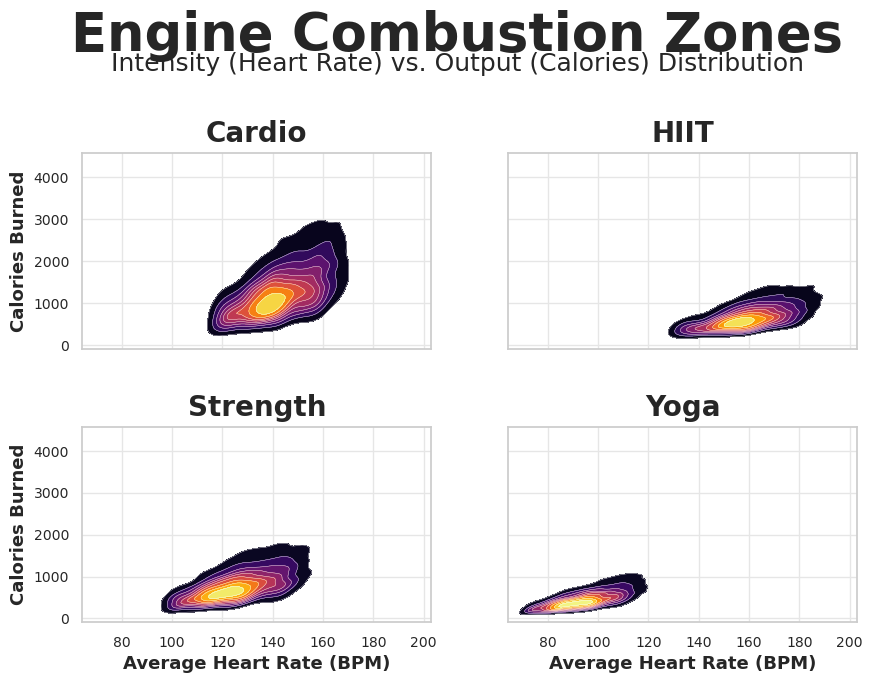

In [9]:
# ============================================================
# PLOT 4: ENGINE HEATMAP 
# ============================================================

workout_order = ["Cardio", "HIIT", "Strength", "Yoga"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, workout in zip(axes, workout_order):

    subset = df[df["workout_type"] == workout]

    # Filled density polygons
    sns.kdeplot(
        data=subset,
        x="avg_bpm",
        y="calories_burned",
        fill=True,
        cmap="inferno",
        levels=10,
        thresh=0.05,
        bw_adjust=1,
        cut=3,
        ax=ax
    )

    # White contour lines
    sns.kdeplot(
        data=subset,
        x="avg_bpm",
        y="calories_burned",
        fill=False,
        color="white",
        levels=10,
        thresh=0.05,
        bw_adjust=1,
        cut=3,
        linewidths=0.3,
        ax=ax
    )

    # Facet titles
    ax.set_title(
        workout,
        fontsize=20,
        weight="bold",
        pad=8
    )

    # Axis labels
    ax.set_xlabel(
        "Average Heart Rate (BPM)",
        fontsize=13,
        weight="bold"
    )

    ax.set_ylabel(
        "Calories Burned",
        fontsize=13,
        weight="bold"
    )

    # Grid
    ax.grid(
        color="#e6e6e6",
        linewidth=1
    )

# ============================================================
# TITLES
# ============================================================

fig.text(
    0.5,
    0.985,
    "Engine Combustion Zones",
    ha="center",
    va="top",
    fontsize=38,
    weight="bold"
)

fig.text(
    0.5,
    0.925,
    "Intensity (Heart Rate) vs. Output (Calories) Distribution",
    ha="center",
    va="top",
    fontsize=18
)

# ============================================================
# SPACING
# ============================================================

fig.subplots_adjust(
    top=0.78,
    hspace=0.40,
    wspace=0.22
)

save_fig(fig, "04_engine_combustion_zones.png")

plt.show()